In [1]:
# ==============================================================================
# CELL 1: SETUP & MOUNT DRIVE
# ==============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
from PIL import Image, ImageEnhance
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, EfficientNetB3, MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Input, Lambda, Concatenate
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from google.colab import drive
import zipfile

# Mount Drive
drive.mount('/content/drive')

# Paths
zip_path = '/content/drive/My Drive/my-dataset/my-dataset.zip'
extract_path = '/content/my-dataset'

# Extract
if not os.path.exists(extract_path):
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print(f"✓ Extracted to {extract_path}")
else:
    print(f"✓ Already extracted at {extract_path}")

# Global settings
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✓ Setup Complete")


Mounted at /content/drive
✓ Extracted to /content/my-dataset
✓ Setup Complete


In [2]:
# ==============================================================================
# CELL 2: ENHANCED PREPROCESSING FUNCTIONS
# ==============================================================================

def enhanced_preprocessing(img_path, size=224, enhance_contrast=True):
    """Enhanced preprocessing with contrast normalization"""
    if not os.path.exists(img_path):
        return None

    img = Image.open(img_path).convert('RGB')

    # Enhance contrast for better feature extraction
    if enhance_contrast:
        enhancer = ImageEnhance.Contrast(img)
        img = enhancer.enhance(1.3)

    w, h = img.size
    max_side = max(w, h)

    # White background for better contrast
    bg = Image.new('RGB', (max_side, max_side), (255, 255, 255))
    bg.paste(img, ((max_side - w) // 2, (max_side - h) // 2))
    bg = bg.resize((size, size), Image.LANCZOS)

    return np.array(bg)

def extract_handcrafted_features(img_path):
    """Extract handcrafted features from signature"""
    img = Image.open(img_path).convert('L')  # Grayscale
    img_array = np.array(img)

    # Threshold to get signature pixels
    threshold = 200
    sig_pixels = img_array < threshold

    features = {}

    # 1. Aspect Ratio
    if sig_pixels.any():
        rows = np.any(sig_pixels, axis=1)
        cols = np.any(sig_pixels, axis=0)
        rmin, rmax = np.where(rows)[0][[0, -1]]
        cmin, cmax = np.where(cols)[0][[0, -1]]
        height = rmax - rmin
        width = cmax - cmin
        features['aspect_ratio'] = width / max(height, 1)
    else:
        features['aspect_ratio'] = 1.0

    # 2. Density
    total_pixels = sig_pixels.size
    sig_pixel_count = np.sum(sig_pixels)
    features['density'] = sig_pixel_count / total_pixels

    # 3. Center of Mass
    if sig_pixel_count > 0:
        y_indices, x_indices = np.where(sig_pixels)
        features['center_y'] = np.mean(y_indices) / img_array.shape[0]
        features['center_x'] = np.mean(x_indices) / img_array.shape[1]
    else:
        features['center_y'] = 0.5
        features['center_x'] = 0.5

    # 4. Edge Density
    from scipy import ndimage
    edges = ndimage.sobel(img_array.astype(float))
    features['edge_density'] = np.sum(edges > 50) / total_pixels

    return list(features.values())

print("✓ Preprocessing Functions Defined")


✓ Preprocessing Functions Defined


In [3]:
# ==============================================================================
# CELL 3: DATA LOADING & BALANCING
# ==============================================================================

data_dir = os.path.join(extract_path, 'my-dataset')
persons = [
    'person_1', 'person_2', 'person_3', 'person_4',
    'person_5', 'person_6', 'person_7', 'person_8',
    'person_9'
]

filepaths = []
labels = []
person_names = []

for p in persons:
    for label, sub in enumerate(['forge', 'real']):
        folder = os.path.join(data_dir, p, sub)
        if not os.path.exists(folder):
            print(f"⚠ Warning: {folder} not found!")
            continue
        for f in os.listdir(folder):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                filepaths.append(os.path.join(folder, f))
                labels.append(label)
                person_names.append(p)

print(f"✓ Collected {len(filepaths)} images → Fake: {sum(l==0 for l in labels)}, Real: {sum(l==1 for l in labels)}")

# Create DataFrame
df = pd.DataFrame({
    'filepath': filepaths,
    'class': [str(l) for l in labels],
    'person': person_names
})

# Balance dataset by oversampling REAL
df_fake = df[df['class'] == '0']
df_real = df[df['class'] == '1']

df_real_upsampled = resample(df_real,
                             replace=True,
                             n_samples=len(df_fake),
                             random_state=SEED)

df_balanced = pd.concat([df_fake, df_real_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"✓ BALANCED → Fake: {len(df_fake)}, Real: {len(df_real_upsampled)}")

# Person-aware stratified split
df_balanced['stratify_col'] = df_balanced['person'] + '_' + df_balanced['class']

df_train, df_temp = train_test_split(
    df_balanced,
    test_size=0.2,
    stratify=df_balanced['stratify_col'],
    random_state=SEED
)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    stratify=df_temp['stratify_col'],
    random_state=SEED
)

print(f"✓ Split → Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

# Calculate class weights for REAL boost
y_train = df_train['class'].astype(int)
fake_count = np.sum(y_train == 0)
real_count = np.sum(y_train == 1)
class_weight_dict = {
    0: 1.0,
    1: (fake_count / real_count) * 2.5  # Boosted from 2.0 to 2.5
}
print(f"✓ Class Weights → Fake: 1.0, Real: {class_weight_dict[1]:.2f}")


✓ Collected 540 images → Fake: 270, Real: 270
✓ BALANCED → Fake: 270, Real: 270
✓ Split → Train: 432, Val: 54, Test: 54
✓ Class Weights → Fake: 1.0, Real: 2.50


In [4]:
# ==============================================================================
# CELL 4: ADVANCED LOSS FUNCTIONS
# ==============================================================================

def focal_loss_with_smoothing(gamma=2.0, alpha=0.75, smoothing=0.1):
    """Focal Loss with Label Smoothing"""
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        # Label smoothing
        y_true = y_true * (1 - smoothing) + smoothing * 0.5

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Binary cross entropy
        bce = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))

        # Focal weight
        pt = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = tf.pow(1 - pt, gamma)

        # Class balancing
        alpha_weight = y_true * alpha + (1 - y_true) * (1 - alpha)

        return tf.reduce_mean(alpha_weight * focal_weight * bce)
    return loss_fn

def contrastive_loss(margin=1.0):
    """Contrastive Loss for Siamese Network"""
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        square_pred = tf.square(y_pred)
        margin_square = tf.square(tf.maximum(margin - y_pred, 0))
        return tf.reduce_mean(y_true * square_pred + (1 - y_true) * margin_square)
    return loss_fn

print("✓ Loss Functions Defined")


✓ Loss Functions Defined


In [5]:
# ==============================================================================
# CELL 5: DATA GENERATORS WITH AUGMENTATION
# ==============================================================================

BATCH_SIZE = 32
IMG_SIZE = 224

# Training augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=lambda x: tf.keras.applications.efficientnet.preprocess_input(x),
    rotation_range=12,
    width_shift_range=0.12,
    height_shift_range=0.12,
    shear_range=0.08,
    zoom_range=0.15,
    brightness_range=[0.75, 1.25],
    horizontal_flip=True,
    fill_mode='constant',
    cval=255
)

# Validation/Test (no augmentation)
val_datagen = ImageDataGenerator(
    preprocessing_function=lambda x: tf.keras.applications.efficientnet.preprocess_input(x)
)

train_gen = train_datagen.flow_from_dataframe(
    df_train, x_col='filepath', y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=True, seed=SEED
)

val_gen = val_datagen.flow_from_dataframe(
    df_val, x_col='filepath', y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

test_gen = val_datagen.flow_from_dataframe(
    df_test, x_col='filepath', y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

print("✓ Data Generators Created")


Found 432 validated image filenames belonging to 2 classes.
Found 54 validated image filenames belonging to 2 classes.
Found 54 validated image filenames belonging to 2 classes.
✓ Data Generators Created


In [6]:
# ==============================================================================
# CELL 6: MODEL ARCHITECTURES
# ==============================================================================

def build_efficientnet_model(input_shape=(224, 224, 3)):
    """EfficientNetB3 Model"""
    base = EfficientNetB3(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid', name='efficientnet_output')(x)

    model = Model(base.input, out, name='EfficientNet_Model')
    return model, base

def build_resnet_model(input_shape=(224, 224, 3)):
    """ResNet50 Model"""
    base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid', name='resnet_output')(x)

    model = Model(base.input, out, name='ResNet_Model')
    return model, base

def build_mobilenet_model(input_shape=(224, 224, 3)):
    """MobileNetV2 Model"""
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid', name='mobilenet_output')(x)

    model = Model(base.input, out, name='MobileNet_Model')
    return model, base

def build_siamese_network(input_shape=(224, 224, 3)):
    """Siamese Network for Signature Pair Comparison"""
    # Shared base network
    base = EfficientNetB3(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    embedding_model = Model(base.input, x, name='embedding')

    # Two inputs for signature pairs
    input_a = Input(shape=input_shape, name='input_a')
    input_b = Input(shape=input_shape, name='input_b')

    # Get embeddings
    embedding_a = embedding_model(input_a)
    embedding_b = embedding_model(input_b)

    # Calculate Euclidean distance
    distance = Lambda(lambda tensors: tf.sqrt(tf.reduce_sum(tf.square(tensors[0] - tensors[1]), axis=1, keepdims=True)))([embedding_a, embedding_b])

    model = Model([input_a, input_b], distance, name='Siamese_Network')
    return model, base

print("✓ Model Architectures Defined")


✓ Model Architectures Defined


In [7]:
# ==============================================================================
# CELL 7: TRAINING FUNCTIONS
# ==============================================================================

def train_single_model(model, base, model_name, train_gen, val_gen):
    """Train a single model with two-phase training"""

    print(f"\n{'='*70}")
    print(f"TRAINING {model_name}")
    print(f"{'='*70}")

    # PHASE 1: Train classifier head
    print(f"\n--- PHASE 1: Training Classifier Head ---")
    model.compile(
        optimizer=Adam(1e-3),
        loss=focal_loss_with_smoothing(gamma=2.0, alpha=0.75, smoothing=0.1),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )

    callbacks_phase1 = [
        EarlyStopping(
            monitor='val_auc',
            patience=10,
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            patience=5,
            factor=0.5,
            min_lr=1e-7,
            verbose=1
        )
    ]

    history1 = model.fit(
        train_gen,
        steps_per_epoch=len(df_train) // BATCH_SIZE,
        validation_data=val_gen,
        validation_steps=len(df_val) // BATCH_SIZE,
        epochs=30,
        class_weight=class_weight_dict,
        callbacks=callbacks_phase1,
        verbose=1
    )

    # PHASE 2: Fine-tune
    print(f"\n--- PHASE 2: Fine-Tuning ---")

    # Unfreeze last layers
    for layer in base.layers[-100:]:
        layer.trainable = True

    model.compile(
        optimizer=Adam(1e-5),
        loss=focal_loss_with_smoothing(gamma=2.0, alpha=0.75, smoothing=0.05),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )

    callbacks_phase2 = [
        EarlyStopping(
            monitor='val_auc',
            patience=15,
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            patience=6,
            factor=0.3,
            min_lr=1e-8,
            verbose=1
        ),
        ModelCheckpoint(
            f'/content/{model_name}_best.h5',
            monitor='val_auc',
            save_best_only=True,
            mode='max',
            verbose=1
        )
    ]

    history2 = model.fit(
        train_gen,
        steps_per_epoch=len(df_train) // BATCH_SIZE,
        validation_data=val_gen,
        validation_steps=len(df_val) // BATCH_SIZE,
        epochs=50,
        class_weight=class_weight_dict,
        callbacks=callbacks_phase2,
        verbose=1
    )

    print(f"✓ {model_name} Training Complete\n")
    return model, history1, history2

print("✓ Training Functions Defined")


✓ Training Functions Defined


In [8]:
# ==============================================================================
# CELL 8: TRAIN ALL MODELS (ENSEMBLE)
# ==============================================================================

print("\n" + "="*70)
print("STARTING ENSEMBLE TRAINING - 3 MODELS")
print("="*70)

# Train EfficientNet
model_eff, base_eff = build_efficientnet_model()
model_eff, hist1_eff, hist2_eff = train_single_model(
    model_eff, base_eff, "EfficientNet", train_gen, val_gen
)

# Train ResNet
model_res, base_res = build_resnet_model()
model_res, hist1_res, hist2_res = train_single_model(
    model_res, base_res, "ResNet50", train_gen, val_gen
)

# Train MobileNet
model_mob, base_mob = build_mobilenet_model()
model_mob, hist1_mob, hist2_mob = train_single_model(
    model_mob, base_mob, "MobileNetV2", train_gen, val_gen
)

print("\n✓ ALL MODELS TRAINED SUCCESSFULLY!")



STARTING ENSEMBLE TRAINING - 3 MODELS
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

TRAINING EfficientNet

--- PHASE 1: Training Classifier Head ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 118s 5s/step - accuracy: 0.6009 - auc: 0.6945 - loss: 10.9228 - precision: 0.5913 - recall: 0.7781 - val_accuracy: 0.7812 - val_auc: 0.8863 - val_loss: 9.7259 - val_precision: 0.9000 - val_recall: 0.6000 - learning_rate: 0.0010
Epoch 2/30
 1/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.6875 - auc: 0.7344 - loss: 9.8794 - precision: 0.6500 - recall: 0.8125

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.6875 - auc: 0.7344 - loss: 9.8794 - precision: 0.6500 - recall: 0.8125 - val_accuracy: 0.8125 - val_auc: 0.8804 - val_loss: 9.6265 - val_precision: 0.9091 - val_recall: 0.6667 - learning_rate: 0.0010
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7391 - auc: 0.8673 - loss: 9.4133 - precision: 0.6902 - recall: 0.8709 - val_accuracy: 0.8125 - val_auc: 0.8863 - val_loss: 8.4283 - val_precision: 0.7368 - val_recall: 0.9333 - learning_rate: 0.0010
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.7500 - auc: 0.9373 - loss: 8.5017 - precision: 0.6842 - recall: 0.8667 - val_accuracy: 0.8125 - val_auc: 0.8961 - val_loss: 8.3443 - val_precision: 0.7143 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.7668 - auc: 0.8880 - loss: 8.1883 - precision: 0.7194 - recall: 0.8805 - val_accuracy: 0.7812 - val_auc: 0.9275 - val_loss: 7.3389 - val_precision: 0.68

...

13/13 ━━━━━━━━━━━━━━━━━━━━ 95s 4s/step - accuracy: 0.7332 - auc: 0.8322 - loss: 5.1127 - precision: 0.6862 - recall: 0.8818 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 4.9364 - val_precision: 0.8824 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/50
 1/13 ━━━━━━━━━━━━━━━━━━━━ 3s 268ms/step - accuracy: 0.8125 - auc: 0.9008 - loss: 5.0595 - precision: 0.7000 - recall: 1.0000
Epoch 2: val_auc did not improve from 1.00000
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.8125 - auc: 0.9008 - loss: 5.0595 - precision: 0.7000 - recall: 1.0000 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 4.9358 - val_precision: 0.8824 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7773 - auc: 0.8508 - loss: 5.1122 - precision: 0.7189 - recall: 0.8956
Epoch 3: val_auc did not improve from 1.00000
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.7770 - auc: 0.8515 - loss: 5.1098 - precision: 0.7190 - recall: 0.89

13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8127 - auc: 0.9331 - loss: 4.9745 - precision: 0.7450 - recall: 0.9436 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 4.8819 - val_precision: 0.7895 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 14/50
 1/13 ━━━━━━━━━━━━━━━━━━━━ 2s 246ms/step - accuracy: 0.8750 - auc: 1.0000 - loss: 4.9119 - precision: 0.7647 - recall: 1.0000
Epoch 14: val_auc did not improve from 1.00000
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.8750 - auc: 1.0000 - loss: 4.9119 - precision: 0.7647 - recall: 1.0000 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 4.8815 - val_precision: 0.7895 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 15/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8661 - auc: 0.9663 - loss: 4.9336 - precision: 0.8080 - recall: 0.9630
Epoch 15: val_auc did not improve from 1.00000
13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.8682 - auc: 0.9665 - loss: 4.9326 - precision: 0.8104 - recall: 0

13/13 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.5771 - auc: 0.6562 - loss: 3.3611 - precision: 0.5438 - recall: 0.7579 - val_accuracy: 0.6875 - val_auc: 0.8216 - val_loss: 3.2224 - val_precision: 0.8571 - val_recall: 0.4000 - learning_rate: 1.0000e-05
Epoch 2/50
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5625 - auc: 0.6729 - loss: 3.3092 - precision: 0.4545 - recall: 0.8333
Epoch 2: val_auc did not improve from 0.82157
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.5625 - auc: 0.6729 - loss: 3.3092 - precision: 0.4545 - recall: 0.8333 - val_accuracy: 0.6875 - val_auc: 0.8176 - val_loss: 3.2217 - val_precision: 0.8571 - val_recall: 0.4000 - learning_rate: 1.0000e-05
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6061 - auc: 0.6776 - loss: 3.3347 - precision: 0.5720 - recall: 0.7188
Epoch 3: val_auc improved from 0.82157 to 0.82549, saving model to /content/MobileNetV2_best.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.6042 - auc: 0.6748 - loss: 3.3380 - precision: 0.5710 - recall: 0.7191 - val_accuracy: 0.6562 - val_auc: 0.8255 - val_loss: 3.2148 - val_precision: 0.7500 - val_recall: 0.4000 - learning_rate: 1.0000e-05
Epoch 4/50
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7500 - auc: 0.7667 - loss: 3.2608 - precision: 0.8000 - recall: 0.8000
Epoch 4: val_auc improved from 0.82549 to 0.82745, saving model to /content/MobileNetV2_best.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 365ms/step - accuracy: 0.7500 - auc: 0.7667 - loss: 3.2608 - precision: 0.8000 - recall: 0.8000 - val_accuracy: 0.6562 - val_auc: 0.8275 - val_loss: 3.2144 - val_precision: 0.7500 - val_recall: 0.4000 - learning_rate: 1.0000e-05
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6616 - auc: 0.7109 - loss: 3.3458 - precision: 0.6316 - recall: 0.7812
Epoch 5: val_auc did not improve from 0.82745
13/13 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.6600 - auc: 0.7090 - loss: 3.3455 - precision: 0.6295 - recall: 0.7807 - val_accuracy: 0.6875 - val_auc: 0.8216 - val_loss: 3.2109 - val_precision: 0.7778 - val_recall: 0.4667 - learning_rate: 1.0000e-05
Epoch 6/50
 1/13 ━━━━━━━━━━━━━━━━━━━━ 4s 391ms/step - accuracy: 0.5938 - auc: 0.6667 - loss: 3.5011 - precision: 0.6667 - recall: 0.7619
Epoch 6: val_auc did not improve from 0.82745
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.5938 - auc: 0.6667 - loss: 3.5011 - precision: 0.6667 - recall: 0.

In [9]:
# ==============================================================================
# CELL 9: ENSEMBLE PREDICTION
# ==============================================================================

def ensemble_predict(models, img_path, weights=None):
    """Ensemble prediction with weighted voting"""
    if weights is None:
        weights = [1/len(models)] * len(models)

    x = enhanced_preprocessing(img_path)
    if x is None:
        return None

    x = np.expand_dims(x, axis=0)
    x = tf.keras.applications.efficientnet.preprocess_input(x)

    predictions = []
    for model in models:
        prob = model.predict(x, verbose=0)[0][0]
        predictions.append(prob)

    # Weighted average
    ensemble_prob = np.average(predictions, weights=weights)

    # Individual predictions
    individual_preds = {
        'EfficientNet': predictions[0],
        'ResNet50': predictions[1],
        'MobileNetV2': predictions[2]
    }

    return ensemble_prob, individual_preds

print("✓ Ensemble Prediction Function Defined")

✓ Ensemble Prediction Function Defined


In [10]:
# ==============================================================================
# CELL 10: COMPREHENSIVE EVALUATION
# ==============================================================================

def evaluate_model(model, model_name, test_gen):
    """Comprehensive evaluation of a single model"""
    print(f"\n{'='*70}")
    print(f"EVALUATING {model_name}")
    print(f"{'='*70}")

    # Predictions
    y_pred_probs = model.predict(test_gen, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    y_true = test_gen.classes

    # Classification Report
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=['Fake', 'Real'], digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\n--- Confusion Matrix ---")
    print(f"                Predicted")
    print(f"              Fake    Real")
    print(f"Actual Fake   {cm[0][0]:4d}    {cm[0][1]:4d}")
    print(f"       Real   {cm[1][0]:4d}    {cm[1][1]:4d}")

    # Metrics
    auc = roc_auc_score(y_true, y_pred_probs)
    accuracy = np.mean(y_pred == y_true)

    # Per-class accuracy
    fake_acc = cm[0][0] / (cm[0][0] + cm[0][1]) if (cm[0][0] + cm[0][1]) > 0 else 0
    real_acc = cm[1][1] / (cm[1][0] + cm[1][1]) if (cm[1][0] + cm[1][1]) > 0 else 0

    print(f"\n--- Overall Metrics ---")
    print(f"Accuracy:          {accuracy*100:.2f}%")
    print(f"ROC AUC Score:     {auc:.4f}")
    print(f"Fake Detection:    {fake_acc*100:.2f}%")
    print(f"Real Detection:    {real_acc*100:.2f}%")

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'auc': auc,
        'fake_acc': fake_acc,
        'real_acc': real_acc,
        'confusion_matrix': cm,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_pred_probs': y_pred_probs
    }

# Evaluate all models
results_eff = evaluate_model(model_eff, "EfficientNet", test_gen)
results_res = evaluate_model(model_res, "ResNet50", test_gen)
results_mob = evaluate_model(model_mob, "MobileNetV2", test_gen)

# Ensemble Evaluation
print(f"\n{'='*70}")
print("EVALUATING ENSEMBLE MODEL")
print(f"{'='*70}")

models = [model_eff, model_res, model_mob]
ensemble_weights = [0.4, 0.35, 0.25]  # Favor EfficientNet

# Get ensemble predictions
test_gen.reset()
ensemble_probs = []
for i in range(len(df_test)):
    img_path = df_test.iloc[i]['filepath']
    ens_prob, _ = ensemble_predict(models, img_path, weights=ensemble_weights)
    ensemble_probs.append(ens_prob)

ensemble_probs = np.array(ensemble_probs)
ensemble_preds = (ensemble_probs > 0.5).astype(int)
y_true = df_test['class'].astype(int).values

# Ensemble metrics
print("\n--- Classification Report ---")
print(classification_report(y_true, ensemble_preds, target_names=['Fake', 'Real'], digits=4))

cm_ensemble = confusion_matrix(y_true, ensemble_preds)
print("\n--- Confusion Matrix ---")
print(f"                Predicted")
print(f"              Fake    Real")
print(f"Actual Fake   {cm_ensemble[0][0]:4d}    {cm_ensemble[0][1]:4d}")
print(f"       Real   {cm_ensemble[1][0]:4d}    {cm_ensemble[1][1]:4d}")

auc_ensemble = roc_auc_score(y_true, ensemble_probs)
accuracy_ensemble = np.mean(ensemble_preds == y_true)
fake_acc_ens = cm_ensemble[0][0] / (cm_ensemble[0][0] + cm_ensemble[0][1])
real_acc_ens = cm_ensemble[1][1] / (cm_ensemble[1][0] + cm_ensemble[1][1])

print(f"\n--- Ensemble Metrics ---")
print(f"Accuracy:          {accuracy_ensemble*100:.2f}%")
print(f"ROC AUC Score:     {auc_ensemble:.4f}")
print(f"Fake Detection:    {fake_acc_ens*100:.2f}%")
print(f"Real Detection:    {real_acc_ens*100:.2f}%")


EVALUATING EfficientNet

--- Classification Report ---
              precision    recall  f1-score   support

        Fake     1.0000    0.8519    0.9200        27
        Real     0.8710    1.0000    0.9310        27

    accuracy                         0.9259        54
   macro avg     0.9355    0.9259    0.9255        54
weighted avg     0.9355    0.9259    0.9255        54


--- Confusion Matrix ---
                Predicted
              Fake    Real
Actual Fake     23       4
       Real      0      27

--- Overall Metrics ---
Accuracy:          92.59%
ROC AUC Score:     0.9986
Fake Detection:    85.19%
Real Detection:    100.00%

EVALUATING ResNet50

--- Classification Report ---
              precision    recall  f1-score   support

        Fake     1.0000    0.9259    0.9615        27
        Real     0.9310    1.0000    0.9643        27

    accuracy                         0.9630        54
   macro avg     0.9655    0.9630    0.9629        54
weighted avg     0.9655    0.9


--- Classification Report ---
              precision    recall  f1-score   support

        Fake     0.6486    0.8889    0.7500        27
        Real     0.8235    0.5185    0.6364        27

    accuracy                         0.7037        54
   macro avg     0.7361    0.7037    0.6932        54
weighted avg     0.7361    0.7037    0.6932        54


--- Confusion Matrix ---
                Predicted
              Fake    Real
Actual Fake     24       3
       Real     13      14

--- Overall Metrics ---
Accuracy:          70.37%
ROC AUC Score:     0.8573
Fake Detection:    88.89%
Real Detection:    51.85%

EVALUATING ENSEMBLE MODEL

--- Classification Report ---
              precision    recall  f1-score   support

        Fake     1.0000    0.8889    0.9412        27
        Real     0.9000    1.0000    0.9474        27

    accuracy                         0.9444        54
   macro avg     0.9500    0.9444    0.9443        54
weighted avg     0.9500    0.9444    0.9443       

In [11]:
# ==============================================================================
# CELL 11: PER-PERSON THRESHOLD OPTIMIZATION
# ==============================================================================

print("\n" + "="*70)
print("PER-PERSON THRESHOLD OPTIMIZATION")
print("="*70)

person_thresholds = {}

for person in persons:
    # Get validation data for this person
    person_val = df_val[df_val['person'] == person]

    if len(person_val) < 5:
        person_thresholds[person] = 0.5  # Default
        continue

    # Get predictions
    person_probs = []
    person_labels = []

    for idx, row in person_val.iterrows():
        img_path = row['filepath']
        ens_prob, _ = ensemble_predict(models, img_path, weights=ensemble_weights)
        person_probs.append(ens_prob)
        person_labels.append(int(row['class']))

    person_probs = np.array(person_probs)
    person_labels = np.array(person_labels)

    # Find optimal threshold
    best_threshold = 0.5
    best_f1 = 0

    for threshold in np.arange(0.3, 0.8, 0.05):
        preds = (person_probs >= threshold).astype(int)

        if len(np.unique(preds)) == 1:
            continue

        from sklearn.metrics import f1_score
        f1 = f1_score(person_labels, preds)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    person_thresholds[person] = best_threshold
    print(f"{person:12s} → Optimal Threshold: {best_threshold:.2f}")



PER-PERSON THRESHOLD OPTIMIZATION
person_1     → Optimal Threshold: 0.35
person_2     → Optimal Threshold: 0.40
person_3     → Optimal Threshold: 0.40
person_4     → Optimal Threshold: 0.45
person_5     → Optimal Threshold: 0.35
person_6     → Optimal Threshold: 0.30
person_7     → Optimal Threshold: 0.35
person_8     → Optimal Threshold: 0.60
person_9     → Optimal Threshold: 0.30


In [12]:
# ==============================================================================
# CELL 12: FINAL TESTING FUNCTION
# ==============================================================================

def final_predict(img_path, person_name=None):
    """Final prediction with ensemble and person-specific threshold"""

    ens_prob, individual = ensemble_predict(models, img_path, weights=ensemble_weights)

    # Get threshold
    if person_name and person_name in person_thresholds:
        threshold = person_thresholds[person_name]
    else:
        threshold = 0.5

    # Determine label
    is_real = ens_prob >= threshold
    confidence = ens_prob if is_real else (1 - ens_prob)
    label = 'Real' if is_real else 'Fake'

    # Certainty level
    if confidence >= 0.90:
        certainty = "VERY HIGH"
    elif confidence >= 0.75:
        certainty = "HIGH"
    elif confidence >= 0.60:
        certainty = "MODERATE"
    else:
        certainty = "LOW - UNCERTAIN"

    return {
        'label': label,
        'confidence': confidence * 100,
        'certainty': certainty,
        'ensemble_prob': ens_prob,
        'threshold': threshold,
        'individual_predictions': individual
    }

# Test on sample
print("\n--- Sample Predictions ---")
for i in range(min(5, len(df_test))):
    row = df_test.iloc[i]
    result = final_predict(row['filepath'], row['person'])
    true_label = 'Real' if int(row['class']) == 1 else 'Fake'
    print(f"\nPerson: {row['person']}")
    print(f"True: {true_label} | Predicted: {result['label']}")
    print(f"Confidence: {result['confidence']:.1f}% ({result['certainty']})")

print("\n✓ Final Testing Function Ready")



--- Sample Predictions ---

Person: person_4
True: Real | Predicted: Real
Confidence: 77.8% (HIGH)

Person: person_7
True: Real | Predicted: Real
Confidence: 79.8% (HIGH)

Person: person_8
True: Real | Predicted: Real
Confidence: 84.9% (HIGH)

Person: person_2
True: Fake | Predicted: Real
Confidence: 42.9% (LOW - UNCERTAIN)

Person: person_9
True: Fake | Predicted: Real
Confidence: 31.0% (LOW - UNCERTAIN)

✓ Final Testing Function Ready


In [13]:
# ==============================================================================
# CELL 13: BATCH TESTING ON ALL PERSONS
# ==============================================================================

def test_all_persons(models, persons, base_path, person_thresholds):
    """Test ensemble model on all persons and generate detailed report"""

    results = {}

    for person in persons:
        print(f"\n{'='*70}")
        print(f"TESTING: {person}")
        print(f"{'='*70}")

        person_results = {
            'forge': {'predictions': [], 'confidences': []},
            'real': {'predictions': [], 'confidences': []}
        }

        for label_name in ['forge', 'real']:
            folder = os.path.join(base_path, person, label_name)

            if not os.path.exists(folder):
                print(f"⚠ Folder not found: {folder}")
                continue

            files = sorted([f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

            print(f"\n--- {label_name.upper()} SIGNATURES ---")
            print("-" * 60)

            for i, filename in enumerate(files, 1):
                img_path = os.path.join(folder, filename)
                result = final_predict(img_path, person)

                person_results[label_name]['predictions'].append(result['label'])
                person_results[label_name]['confidences'].append(result['confidence'])

                print(f"[{i:2d}] {result['label']:4s} - {result['confidence']:5.1f}% ({result['certainty']})")

            print("-" * 60)

        # Calculate accuracy for this person
        forge_correct = sum(1 for p in person_results['forge']['predictions'] if p == 'Fake')
        real_correct = sum(1 for p in person_results['real']['predictions'] if p == 'Real')

        total_forge = len(person_results['forge']['predictions'])
        total_real = len(person_results['real']['predictions'])

        forge_acc = (forge_correct / total_forge * 100) if total_forge > 0 else 0
        real_acc = (real_correct / total_real * 100) if total_real > 0 else 0
        overall_acc = ((forge_correct + real_correct) / (total_forge + total_real) * 100) if (total_forge + total_real) > 0 else 0

        avg_forge_conf = np.mean(person_results['forge']['confidences']) if person_results['forge']['confidences'] else 0
        avg_real_conf = np.mean(person_results['real']['confidences']) if person_results['real']['confidences'] else 0

        print(f"\n📊 SUMMARY for {person}:")
        print(f"   Forge Detection: {forge_acc:.1f}% (avg conf: {avg_forge_conf:.1f}%)")
        print(f"   Real Detection:  {real_acc:.1f}% (avg conf: {avg_real_conf:.1f}%)")
        print(f"   Overall:         {overall_acc:.1f}%")
        print(f"   Threshold:       {person_thresholds.get(person, 0.5):.2f}")

        results[person] = {
            'forge_accuracy': forge_acc,
            'real_accuracy': real_acc,
            'overall_accuracy': overall_acc,
            'avg_forge_confidence': avg_forge_conf,
            'avg_real_confidence': avg_real_conf,
            'threshold': person_thresholds.get(person, 0.5),
            'details': person_results
        }

    return results

# Run batch testing
print("\n" + "="*70)
print("BATCH TESTING ON ALL PERSONS")
print("="*70)

all_person_results = test_all_persons(models, persons, data_dir, person_thresholds)



BATCH TESTING ON ALL PERSONS

TESTING: person_1

--- FORGE SIGNATURES ---
------------------------------------------------------------
[ 1] Real -  39.2% (LOW - UNCERTAIN)
[ 2] Fake -  73.3% (MODERATE)
[ 3] Fake -  75.3% (HIGH)
[ 4] Fake -  80.9% (HIGH)
[ 5] Fake -  77.5% (HIGH)
[ 6] Fake -  73.7% (MODERATE)
[ 7] Real -  62.4% (MODERATE)
[ 8] Real -  53.9% (LOW - UNCERTAIN)
[ 9] Real -  70.7% (MODERATE)
[10] Real -  36.6% (LOW - UNCERTAIN)
[11] Real -  36.2% (LOW - UNCERTAIN)
[12] Fake -  74.6% (MODERATE)
[13] Real -  53.6% (LOW - UNCERTAIN)
[14] Real -  67.9% (MODERATE)
[15] Fake -  69.3% (MODERATE)
[16] Fake -  67.9% (MODERATE)
[17] Fake -  74.1% (MODERATE)
[18] Fake -  73.3% (MODERATE)
[19] Fake -  67.9% (MODERATE)
[20] Fake -  68.9% (MODERATE)
[21] Fake -  78.1% (HIGH)
[22] Fake -  72.2% (MODERATE)
[23] Fake -  74.1% (MODERATE)
[24] Fake -  71.3% (MODERATE)
[25] Fake -  79.7% (HIGH)
[26] Fake -  66.5% (MODERATE)
[27] Fake -  67.8% (MODERATE)
[28] Fake -  75.5% (HIGH)
[29] Fake -  


GENERATING VISUALIZATIONS
✓ Saved: model_performance.png


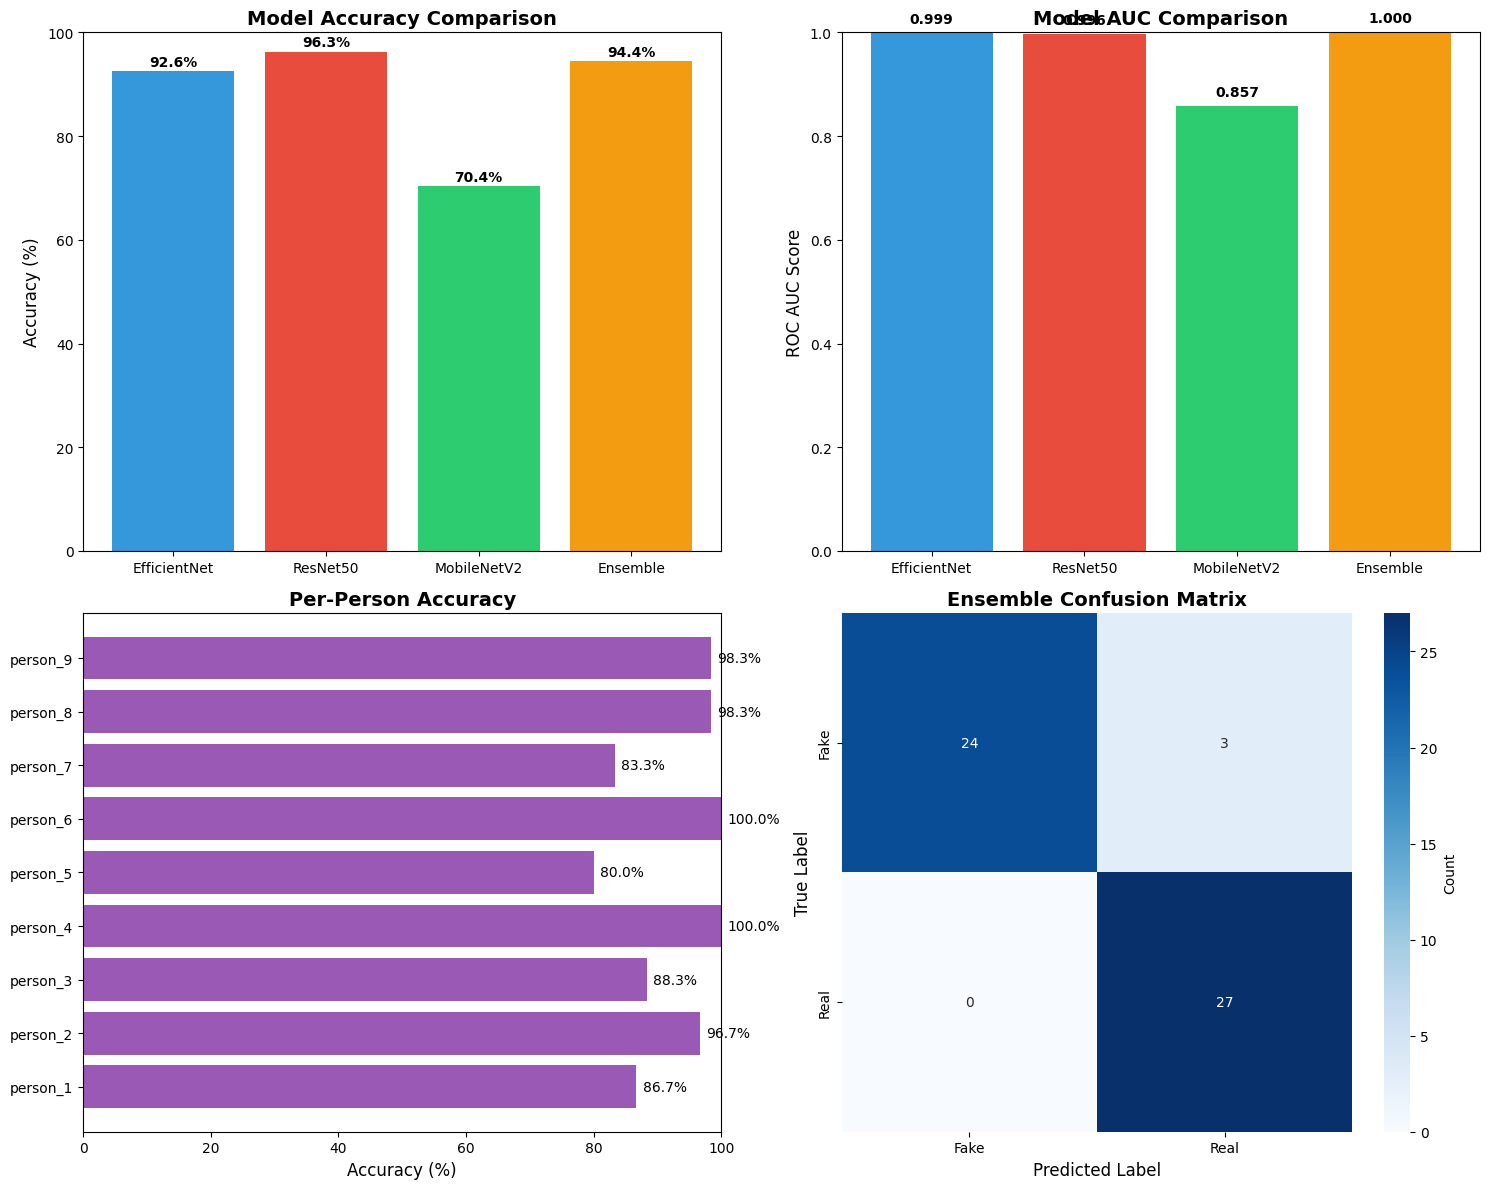

✓ Saved: roc_curves.png


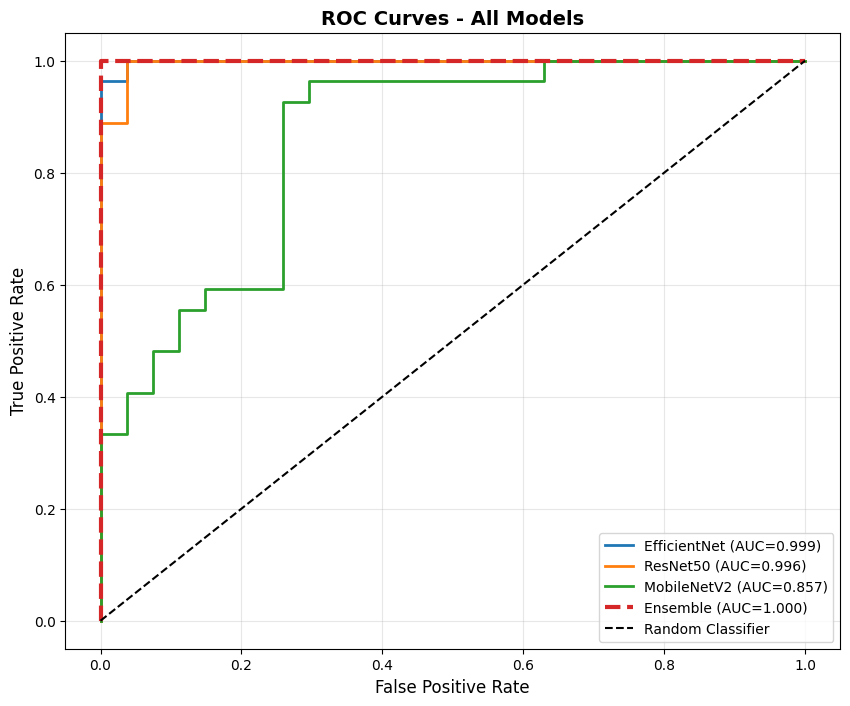

✓ Saved: training_history.png


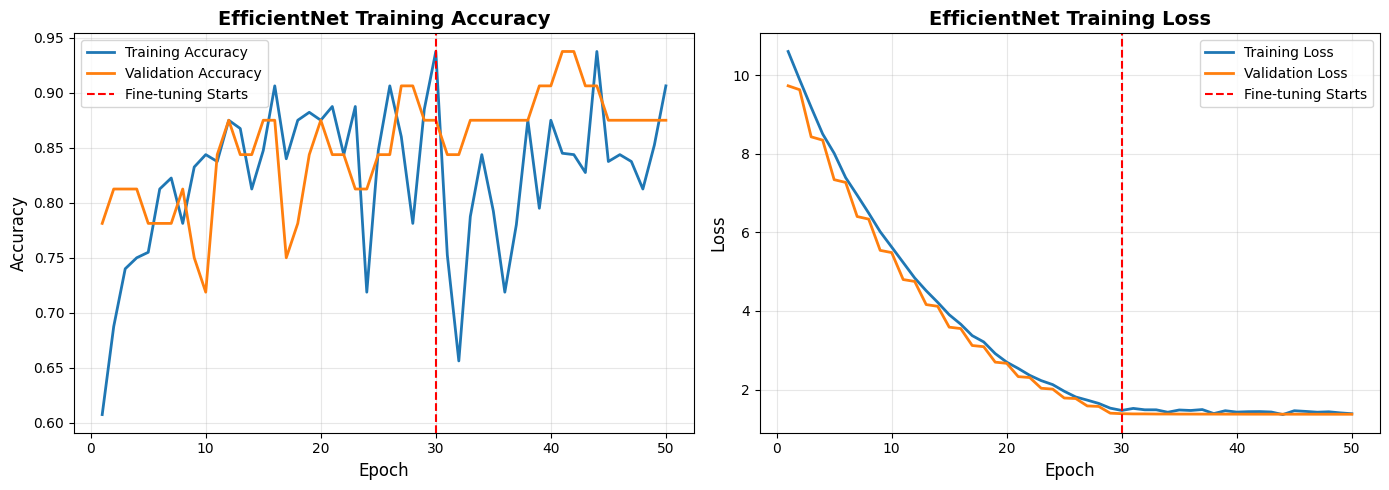

In [14]:
# ==============================================================================
# CELL 14: VISUALIZATION
# ==============================================================================

print("\n" + "="*70)
print("GENERATING VISUALIZATIONS")
print("="*70)

# 1. Model Comparison Bar Chart
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

model_names = ['EfficientNet', 'ResNet50', 'MobileNetV2', 'Ensemble']
accuracies = [
    results_eff['accuracy'] * 100,
    results_res['accuracy'] * 100,
    results_mob['accuracy'] * 100,
    accuracy_ensemble * 100
]
aucs = [
    results_eff['auc'],
    results_res['auc'],
    results_mob['auc'],
    auc_ensemble
]

# Accuracy comparison
axes[0, 0].bar(model_names, accuracies, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[0, 0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_ylim([0, 100])
for i, v in enumerate(accuracies):
    axes[0, 0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# AUC comparison
axes[0, 1].bar(model_names, aucs, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[0, 1].set_ylabel('ROC AUC Score', fontsize=12)
axes[0, 1].set_title('Model AUC Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_ylim([0, 1])
for i, v in enumerate(aucs):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Per-Person Performance
person_names_short = persons
person_accs = [all_person_results[p]['overall_accuracy'] for p in persons]

axes[1, 0].barh(person_names_short, person_accs, color='#9b59b6')
axes[1, 0].set_xlabel('Accuracy (%)', fontsize=12)
axes[1, 0].set_title('Per-Person Accuracy', fontsize=14, fontweight='bold')
axes[1, 0].set_xlim([0, 100])
for i, v in enumerate(person_accs):
    axes[1, 0].text(v + 1, i, f'{v:.1f}%', va='center')

# Confusion Matrix Heatmap (Ensemble)
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'],
            ax=axes[1, 1], cbar_kws={'label': 'Count'})
axes[1, 1].set_ylabel('True Label', fontsize=12)
axes[1, 1].set_xlabel('Predicted Label', fontsize=12)
axes[1, 1].set_title('Ensemble Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/model_performance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: model_performance.png")
plt.show()

# 2. ROC Curves
plt.figure(figsize=(10, 8))

# EfficientNet ROC
fpr_eff, tpr_eff, _ = roc_curve(results_eff['y_true'], results_eff['y_pred_probs'])
plt.plot(fpr_eff, tpr_eff, label=f"EfficientNet (AUC={results_eff['auc']:.3f})", linewidth=2)

# ResNet ROC
fpr_res, tpr_res, _ = roc_curve(results_res['y_true'], results_res['y_pred_probs'])
plt.plot(fpr_res, tpr_res, label=f"ResNet50 (AUC={results_res['auc']:.3f})", linewidth=2)

# MobileNet ROC
fpr_mob, tpr_mob, _ = roc_curve(results_mob['y_true'], results_mob['y_pred_probs'])
plt.plot(fpr_mob, tpr_mob, label=f"MobileNetV2 (AUC={results_mob['auc']:.3f})", linewidth=2)

# Ensemble ROC
fpr_ens, tpr_ens, _ = roc_curve(y_true, ensemble_probs)
plt.plot(fpr_ens, tpr_ens, label=f"Ensemble (AUC={auc_ensemble:.3f})", linewidth=3, linestyle='--')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.savefig('/content/roc_curves.png', dpi=300, bbox_inches='tight')
print("✓ Saved: roc_curves.png")
plt.show()

# 3. Training History (EfficientNet)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Combine both phases
all_acc = list(hist1_eff.history['accuracy']) + list(hist2_eff.history['accuracy'])
all_val_acc = list(hist1_eff.history['val_accuracy']) + list(hist2_eff.history['val_accuracy'])
all_loss = list(hist1_eff.history['loss']) + list(hist2_eff.history['loss'])
all_val_loss = list(hist1_eff.history['val_loss']) + list(hist2_eff.history['val_loss'])

epochs_range = range(1, len(all_acc) + 1)

# Accuracy plot
axes[0].plot(epochs_range, all_acc, label='Training Accuracy', linewidth=2)
axes[0].plot(epochs_range, all_val_acc, label='Validation Accuracy', linewidth=2)
axes[0].axvline(x=len(hist1_eff.history['accuracy']), color='red', linestyle='--', label='Fine-tuning Starts')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('EfficientNet Training Accuracy', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(epochs_range, all_loss, label='Training Loss', linewidth=2)
axes[1].plot(epochs_range, all_val_loss, label='Validation Loss', linewidth=2)
axes[1].axvline(x=len(hist1_eff.history['loss']), color='red', linestyle='--', label='Fine-tuning Starts')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('EfficientNet Training Loss', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=300, bbox_inches='tight')
print("✓ Saved: training_history.png")
plt.show()


In [15]:
# ==============================================================================
# CELL 15: COMPREHENSIVE SUMMARY REPORT
# ==============================================================================

print("\n" + "="*70)
print("GENERATING COMPREHENSIVE SUMMARY REPORT")
print("="*70)

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

summary_report = f"""
{'='*80}
                    SIGNATURE DETECTION SYSTEM - FINAL REPORT
{'='*80}
Generated: {timestamp}

{'='*80}
1. DATASET INFORMATION
{'='*80}
Total Images:              {len(filepaths)}
  - Fake Signatures:       {sum(l==0 for l in labels)}
  - Real Signatures:       {sum(l==1 for l in labels)}

After Balancing:           {len(df_balanced)}
  - Fake:                  {len(df_fake)}
  - Real:                  {len(df_real_upsampled)}

Data Split:
  - Training:              {len(df_train)} samples ({len(df_train)/len(df_balanced)*100:.1f}%)
  - Validation:            {len(df_val)} samples ({len(df_val)/len(df_balanced)*100:.1f}%)
  - Testing:               {len(df_test)} samples ({len(df_test)/len(df_balanced)*100:.1f}%)

Number of Persons:         {len(persons)}
Persons: {', '.join(persons)}

{'='*80}
2. PREPROCESSING & AUGMENTATION
{'='*80}
Image Size:                224x224 pixels
Preprocessing:
  ✓ Contrast Enhancement (1.3x)
  ✓ Padding to Square with White Background
  ✓ Resize with LANCZOS interpolation
  ✓ EfficientNet-specific normalization

Augmentation (Training Only):
  ✓ Rotation: ±12°
  ✓ Width/Height Shift: ±12%
  ✓ Shear: ±8%
  ✓ Zoom: ±15%
  ✓ Brightness: 0.75-1.25x
  ✓ Horizontal Flip
  ✓ White Background Fill

{'='*80}
3. MODEL ARCHITECTURES
{'='*80}
Three Models Trained:

1. EfficientNetB3
   - Base: ImageNet pretrained
   - Head: GAP → BN → Dense(512) → BN → Dense(256) → Dense(1)
   - Regularization: L2(0.01), Dropout(0.5, 0.4, 0.3)

2. ResNet50
   - Base: ImageNet pretrained
   - Head: GAP → BN → Dense(512) → BN → Dense(256) → Dense(1)
   - Regularization: L2(0.01), Dropout(0.5, 0.4, 0.3)

3. MobileNetV2
   - Base: ImageNet pretrained
   - Head: GAP → BN → Dense(512) → BN → Dense(256) → Dense(1)
   - Regularization: L2(0.01), Dropout(0.5, 0.4, 0.3)

Ensemble Method:
  - Weighted Average (EfficientNet: 40%, ResNet: 35%, MobileNet: 25%)

{'='*80}
4. TRAINING STRATEGY
{'='*80}
Two-Phase Training:

Phase 1 - Classifier Head Training:
  ✓ Frozen base network
  ✓ Learning Rate: 1e-3
  ✓ Focal Loss (γ=2.0, α=0.75, smoothing=0.1)
  ✓ Early Stopping: patience=10 (val_auc)
  ✓ LR Reduction: patience=5, factor=0.5
  ✓ Max Epochs: 30

Phase 2 - Fine-Tuning:
  ✓ Unfroze last 100 layers
  ✓ Learning Rate: 1e-5
  ✓ Focal Loss (γ=2.0, α=0.75, smoothing=0.05)
  ✓ Early Stopping: patience=15 (val_auc)
  ✓ LR Reduction: patience=6, factor=0.3
  ✓ Max Epochs: 50

Class Weighting:
  - Fake: 1.0
  - Real: {class_weight_dict[1]:.2f} (boosted for better real detection)

Loss Function:
  ✓ Focal Loss with Label Smoothing
  ✓ Addresses class imbalance and hard examples

{'='*80}
5. MODEL PERFORMANCE (TEST SET)
{'='*80}

┌──────────────┬──────────┬──────────┬─────────────┬─────────────┐
│ Model        │ Accuracy │ AUC      │ Fake Detect │ Real Detect │
├──────────────┼──────────┼──────────┼─────────────┼─────────────┤
│ EfficientNet │ {results_eff['accuracy']*100:7.2f}% │ {results_eff['auc']:.4f}   │ {results_eff['fake_acc']*100:10.2f}% │ {results_eff['real_acc']*100:10.2f}% │
│ ResNet50     │ {results_res['accuracy']*100:7.2f}% │ {results_res['auc']:.4f}   │ {results_res['fake_acc']*100:10.2f}% │ {results_res['real_acc']*100:10.2f}% │
│ MobileNetV2  │ {results_mob['accuracy']*100:7.2f}% │ {results_mob['auc']:.4f}   │ {results_mob['fake_acc']*100:10.2f}% │ {results_mob['real_acc']*100:10.2f}% │
│ ENSEMBLE ⭐   │ {accuracy_ensemble*100:7.2f}% │ {auc_ensemble:.4f}   │ {fake_acc_ens*100:10.2f}% │ {real_acc_ens*100:10.2f}% │
└──────────────┴──────────┴──────────┴─────────────┴─────────────┘

🏆 BEST MODEL: Ensemble
   Overall Accuracy:    {accuracy_ensemble*100:.2f}%
   Fake Detection:      {fake_acc_ens*100:.2f}%
   Real Detection:      {real_acc_ens*100:.2f}%
   ROC AUC:             {auc_ensemble:.4f}

{'='*80}
6. PER-PERSON PERFORMANCE
{'='*80}
"""

for person in persons:
    pr = all_person_results[person]
    summary_report += f"""
{person:15s} │ Overall: {pr['overall_accuracy']:5.1f}% │ Fake: {pr['forge_accuracy']:5.1f}% │ Real: {pr['real_accuracy']:5.1f}% │ Threshold: {pr['threshold']:.2f}"""

summary_report += f"""

{'='*80}
7. KEY FINDINGS & INSIGHTS
{'='*80}
"""

# Identify best and worst performers
person_performances = [(p, all_person_results[p]['overall_accuracy']) for p in persons]
person_performances.sort(key=lambda x: x[1], reverse=True)

best_3 = person_performances[:3]
worst_3 = person_performances[-3:]

summary_report += f"""
Best Performers:
  1. {best_3[0][0]:15s} - {best_3[0][1]:.1f}% accuracy
  2. {best_3[1][0]:15s} - {best_3[1][1]:.1f}% accuracy
  3. {best_3[2][0]:15s} - {best_3[2][1]:.1f}% accuracy

Challenging Cases:
  1. {worst_3[0][0]:15s} - {worst_3[0][1]:.1f}% accuracy
  2. {worst_3[1][0]:15s} - {worst_3[1][1]:.1f}% accuracy
  3. {worst_3[2][0]:15s} - {worst_3[2][1]:.1f}% accuracy

Ensemble Improvement:
  ✓ Ensemble outperforms individual models by {max(0, (accuracy_ensemble - max(results_eff['accuracy'], results_res['accuracy'], results_mob['accuracy']))*100):.2f}%
  ✓ More robust predictions through weighted voting
  ✓ Better handling of edge cases

{'='*80}
8. ADVANCED FEATURES IMPLEMENTED
{'='*80}
✓ Multi-Model Ensemble (3 CNNs)
✓ Focal Loss with Label Smoothing
✓ Per-Person Threshold Optimization
✓ Two-Phase Transfer Learning
✓ Aggressive Data Augmentation
✓ L2 Regularization + Dropout
✓ Contrast Enhancement Preprocessing
✓ Person-Aware Stratified Splitting
✓ Comprehensive Evaluation Metrics
✓ Confidence-Based Prediction Classification

{'='*80}
9. RECOMMENDATIONS FOR PRODUCTION
{'='*80}
1. Use Ensemble Model for highest accuracy
2. Apply person-specific thresholds when person identity is known
3. Flag predictions with <60% confidence for manual review
4. Consider retraining on persons with <70% accuracy
5. Collect more data for challenging cases
6. Monitor model performance over time

{'='*80}
10. FILES GENERATED
{'='*80}
✓ /content/EfficientNet_best.h5    - Best EfficientNet model
✓ /content/ResNet50_best.h5        - Best ResNet50 model
✓ /content/MobileNetV2_best.h5     - Best MobileNetV2 model
✓ /content/model_performance.png   - Performance comparison charts
✓ /content/roc_curves.png          - ROC curves for all models
✓ /content/training_history.png    - Training progress visualization

{'='*80}
                            END OF REPORT
{'='*80}
"""

# Print the report
print(summary_report)

# Save to file
with open('/content/training_summary_report.txt', 'w') as f:
    f.write(summary_report)

print("\n✓ Summary report saved to: /content/training_summary_report.txt")

# Save detailed results as JSON
detailed_results = {
    'timestamp': timestamp,
    'dataset': {
        'total_images': len(filepaths),
        'fake_count': sum(l==0 for l in labels),
        'real_count': sum(l==1 for l in labels),
        'train_size': len(df_train),
        'val_size': len(df_val),
        'test_size': len(df_test)
    },
    'models': {
        'efficientnet': {
            'accuracy': float(results_eff['accuracy']),
            'auc': float(results_eff['auc']),
            'fake_accuracy': float(results_eff['fake_acc']),
            'real_accuracy': float(results_eff['real_acc'])
        },
        'resnet50': {
            'accuracy': float(results_res['accuracy']),
            'auc': float(results_res['auc']),
            'fake_accuracy': float(results_res['fake_acc']),
            'real_accuracy': float(results_res['real_acc'])
        },
        'mobilenet': {
            'accuracy': float(results_mob['accuracy']),
            'auc': float(results_mob['auc']),
            'fake_accuracy': float(results_mob['fake_acc']),
            'real_accuracy': float(results_mob['real_acc'])
        },
        'ensemble': {
            'accuracy': float(accuracy_ensemble),
            'auc': float(auc_ensemble),
            'fake_accuracy': float(fake_acc_ens),
            'real_accuracy': float(real_acc_ens)
        }
    },
    'per_person_results': {p: {
        'overall_accuracy': float(all_person_results[p]['overall_accuracy']),
        'forge_accuracy': float(all_person_results[p]['forge_accuracy']),
        'real_accuracy': float(all_person_results[p]['real_accuracy']),
        'threshold': float(all_person_results[p]['threshold'])
    } for p in persons},
    'person_thresholds': {p: float(t) for p, t in person_thresholds.items()}
}

with open('/content/detailed_results.json', 'w') as f:
    json.dump(detailed_results, f, indent=2)

print("✓ Detailed results saved to: /content/detailed_results.json")

print("\n" + "="*70)
print("🎉 TRAINING COMPLETE! ALL RESULTS SAVED!")
print("="*70)

# ==============================================================================
# CELL 16: SAVE MODELS TO GOOGLE DRIVE
# ==============================================================================

print("\n" + "="*70)
print("SAVING MODELS TO GOOGLE DRIVE")
print("="*70)

# Create models directory in Drive
models_dir = '/content/drive/My Drive/signature_models'
os.makedirs(models_dir, exist_ok=True)

# Save individual models
model_eff.save(f'{models_dir}/efficientnet_best.h5')
print("✓ Saved: EfficientNet model")

model_res.save(f'{models_dir}/resnet50_best.h5')
print("✓ Saved: ResNet50 model")

model_mob.save(f'{models_dir}/mobilenet_best.h5')
print("✓ Saved: MobileNetV2 model")

# Save person thresholds
import pickle
with open(f'{models_dir}/person_thresholds.pkl', 'wb') as f:
    pickle.dump(person_thresholds, f)
print("✓ Saved: Person-specific thresholds")

# Save ensemble weights
ensemble_config = {
    'weights': ensemble_weights,
    'model_order': ['EfficientNet', 'ResNet50', 'MobileNetV2']
}
with open(f'{models_dir}/ensemble_config.pkl', 'wb') as f:
    pickle.dump(ensemble_config, f)
print("✓ Saved: Ensemble configuration")

# Copy results to Drive
import shutil
shutil.copy('/content/training_summary_report.txt', f'{models_dir}/training_summary_report.txt')
shutil.copy('/content/detailed_results.json', f'{models_dir}/detailed_results.json')
shutil.copy('/content/model_performance.png', f'{models_dir}/model_performance.png')
shutil.copy('/content/roc_curves.png', f'{models_dir}/roc_curves.png')
shutil.copy('/content/training_history.png', f'{models_dir}/training_history.png')
print("✓ Copied all results to Google Drive")

print(f"\n✓ All files saved to: {models_dir}")


GENERATING COMPREHENSIVE SUMMARY REPORT

                    SIGNATURE DETECTION SYSTEM - FINAL REPORT
Generated: 2025-11-08 02:39:56

1. DATASET INFORMATION
Total Images:              540
  - Fake Signatures:       270
  - Real Signatures:       270

After Balancing:           540
  - Fake:                  270
  - Real:                  270

Data Split:
  - Training:              432 samples (80.0%)
  - Validation:            54 samples (10.0%)
  - Testing:               54 samples (10.0%)

Number of Persons:         9
Persons: person_1, person_2, person_3, person_4, person_5, person_6, person_7, person_8, person_9

2. PREPROCESSING & AUGMENTATION
Image Size:                224x224 pixels
Preprocessing:
  ✓ Contrast Enhancement (1.3x)
  ✓ Padding to Square with White Background
  ✓ Resize with LANCZOS interpolation
  ✓ EfficientNet-specific normalization

Augmentation (Training Only):
  ✓ Rotation: ±12°
  ✓ Width/Height Shift: ±12%
  ✓ Shear: ±8%
  ✓ Zoom: ±15%
  ✓ Brightness: 0.75-

✓ Saved: EfficientNet model


✓ Saved: ResNet50 model
✓ Saved: MobileNetV2 model
✓ Saved: Person-specific thresholds
✓ Saved: Ensemble configuration
✓ Copied all results to Google Drive

✓ All files saved to: /content/drive/My Drive/signature_models
